In [1]:
import pickle
import functools

from notebooks.utils import (
    generate_layerwise_visualization_v3,
    plot_comparison_with_agreement,
    is_pair_interesting
)

In [2]:
from transformers import AutoConfig

config = AutoConfig.from_pretrained("castorini/monobert-large-msmarco")

NUM_HEADS = config.num_attention_heads
NUM_LAYERS = config.num_hidden_layers
HIDDEN_DIM = config.intermediate_size

print(f"NUM_HEADS: {NUM_HEADS}, NUM_LAYERS: {NUM_LAYERS}, HIDDEN_DIM: {HIDDEN_DIM}")

/home/vast/CE-relevance-integration/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/home/vast/CE-relevance-integration/.venv/lib/python3.10/site-packages/transformers/utils/hub.py:124: FutureWarning: Using `TRANSFORMERS_CACHE` is deprecated and will be removed in v5 of Transformers. Use `HF_HOME` instead.
  warnings.warn(
/home/vast/CE-relevance-integration/.venv/lib/python3.10/site-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


NUM_HEADS: 16, NUM_LAYERS: 24, HIDDEN_DIM: 4096


<Figure size 640x480 with 0 Axes>

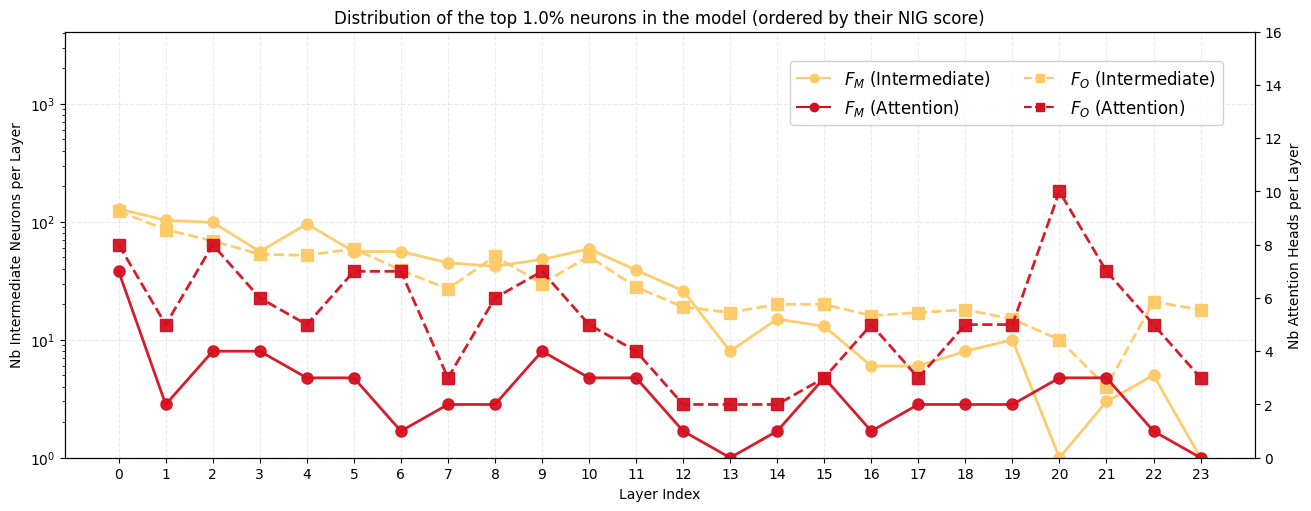

In [4]:
model = "monobert"
percentage = 0.01
names = ["msmarco_fusion", "OOD_fusion"]
paths = [
    f"/home/vast/target_dir/ri-neurons-attribution/jobs/src.ablation.ablation_infonce.ablationschemes/f17eb6691da3c0d6016d18967c76112e1e2f6afaad1b810150c3d30a3af6c35c/ablation_schemes_at_percentage{percentage}_{name}.pkl" for name in names
]
generate_layerwise_visualization_v3(
    paths,
    num_layers=NUM_LAYERS,
    num_heads=NUM_HEADS,
    hidden_dim=HIDDEN_DIM,
    percentage=percentage,
    types=names,
    model=model
)

<Figure size 640x480 with 0 Axes>

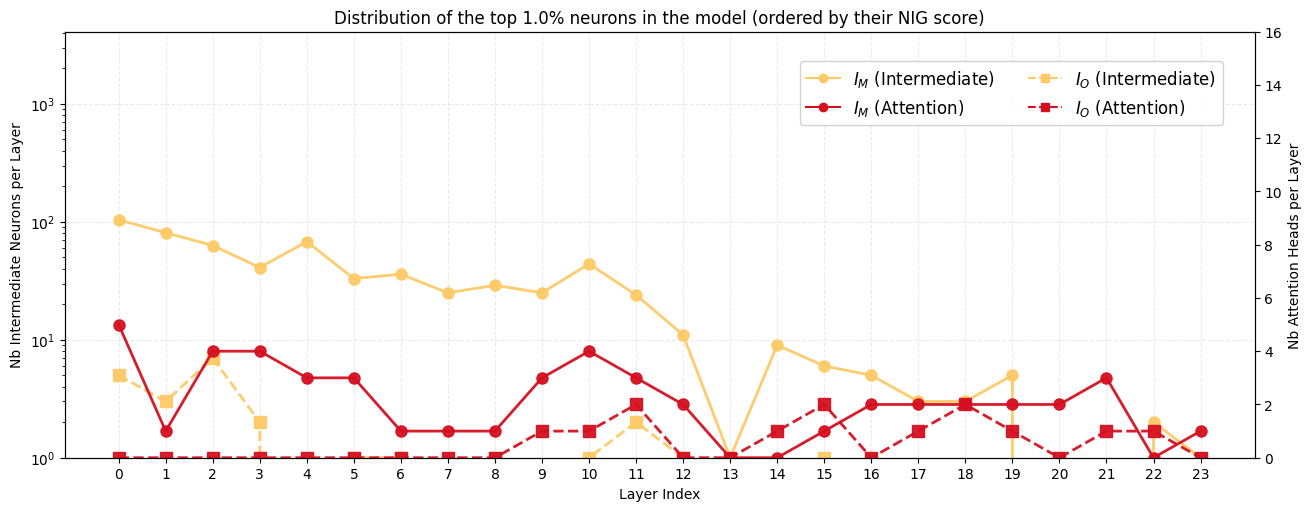

In [5]:
model = "monobert"
percentage = 0.01
names = ["msmarco_intersection", "OOD_intersection"]
paths = [
    f"/home/vast/target_dir/ri-neurons-attribution/jobs/src.ablation.ablation_infonce.ablationschemes/f17eb6691da3c0d6016d18967c76112e1e2f6afaad1b810150c3d30a3af6c35c/ablation_schemes_at_percentage{percentage}_{name}.pkl" for name in names
]
generate_layerwise_visualization_v3(
    paths,
    num_layers=NUM_LAYERS,
    num_heads=NUM_HEADS,
    hidden_dim=HIDDEN_DIM,
    percentage=percentage,
    types=names,
    model=model
)

<Figure size 640x480 with 0 Axes>

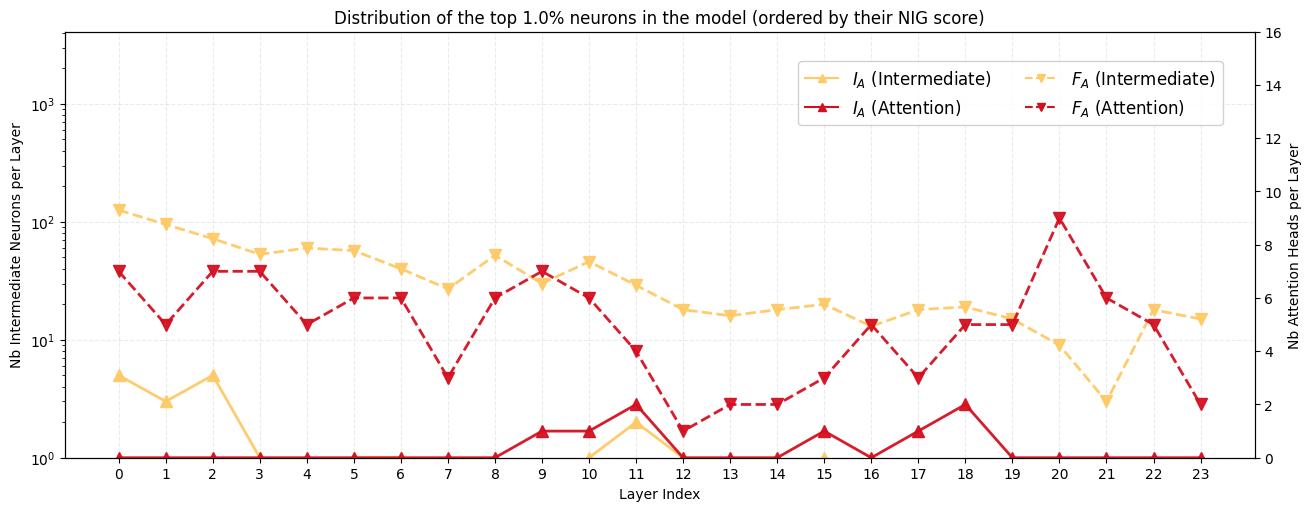

In [6]:
model = "monobert"
percentage = 0.01
names = ["ALL_intersection", "ALL_fusion"]
paths = [
    f"/home/vast/target_dir/ri-neurons-attribution/jobs/src.ablation.ablation_infonce.ablationschemes/f17eb6691da3c0d6016d18967c76112e1e2f6afaad1b810150c3d30a3af6c35c/ablation_schemes_at_percentage{percentage}_{name}.pkl" for name in names
]
generate_layerwise_visualization_v3(
    paths,
    num_layers=NUM_LAYERS,
    num_heads=NUM_HEADS,
    hidden_dim=HIDDEN_DIM,
    percentage=percentage,
    types=names,
    model=model
)

/home/vast/CE-relevance-integration/src/notebooks/utils.py:616: UserWarning: Attempt to set non-positive ylim on a log-scaled axis will be ignored.
  ax1.set_ylim(bottom=0, top=100)


<Figure size 640x480 with 0 Axes>

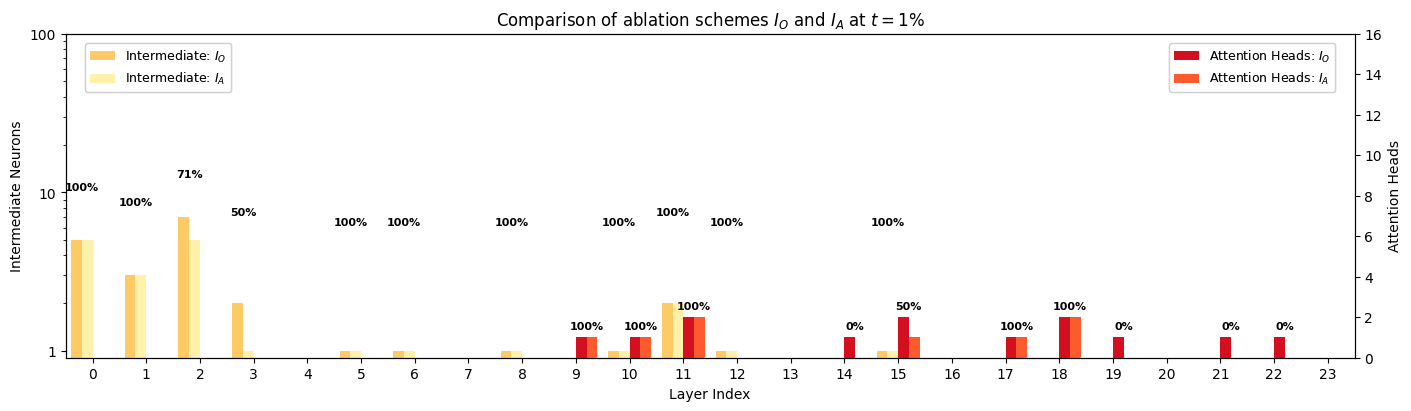

In [7]:
percentage = 0.01    
path1 = f"/home/vast/target_dir/ri-neurons-attribution/jobs/src.ablation.ablation_infonce.ablationschemes/f17eb6691da3c0d6016d18967c76112e1e2f6afaad1b810150c3d30a3af6c35c/ablation_schemes_at_percentage{percentage}_OOD_intersection.pkl"
path2 = f"/home/vast/target_dir/ri-neurons-attribution/jobs/src.ablation.ablation_infonce.ablationschemes/f17eb6691da3c0d6016d18967c76112e1e2f6afaad1b810150c3d30a3af6c35c/ablation_schemes_at_percentage{percentage}_ALL_intersection.pkl"
model_name = "monobert_large"

with open(path1, "rb") as f1, open(path2, "rb") as f2:
    raw1 = pickle.load(f1)
    raw2 = pickle.load(f2)

plot_comparison_with_agreement(
    raw1, raw2,
    num_layers=NUM_LAYERS,
    num_heads=NUM_HEADS,
    hidden_dim=HIDDEN_DIM,
    percentage=percentage,
    model_name=model_name
)

In [8]:
target_modules_regex = ["attention_probs"]

nig_pkl_files = [
    "/home/vast/target_dir/ri-neurons-attribution/jobs/src.xps.aggregation.aggregationresults/080ee0b7f8f83a9e57d43d1d9271752fbb4a5ff4b5ca314de0d33de76ff07cf5/aggregation_result.pkl",
    "/home/vast/target_dir/ri-neurons-attribution/jobs/src.xps.aggregation.aggregationresults/9f39fe5bc933cb585af8fafbdaf94f952306017360d3f545ac7c3decfab4e718/aggregation_result.pkl",
    "/home/vast/target_dir/ri-neurons-attribution/jobs/src.xps.aggregation.aggregationresults/2b2aa5125d04ef51de43d6f9fe8ebc8a455499223d397417c279f432ad636e21/aggregation_result.pkl",
    "/home/vast/target_dir/ri-neurons-attribution/jobs/src.xps.aggregation.aggregationresults/8118bf166f3b60ff34301c0d2870e4cfa624ece5170dfc4d0fc459f96134b48e/aggregation_result.pkl",
    "/home/vast/target_dir/ri-neurons-attribution/jobs/src.xps.aggregation.aggregationresults/a7e5f17180a9e4ddcd28c091a19c5237322d635427e0ade0af334a3e7fded57d/aggregation_result.pkl",
    "/home/vast/target_dir/ri-neurons-attribution/jobs/src.xps.aggregation.aggregationresults/405432d64f2b2a1ddce780487ffe175f86d56cac36f6b4deff50d407f3a2baf2/aggregation_result.pkl",
    "/home/vast/target_dir/ri-neurons-attribution/jobs/src.xps.aggregation.aggregationresults/9ec072ea8f29693f35c8ac0efac8c7d70f572940f8d43a17984efbd540e8aae8/aggregation_result.pkl",
    "/home/vast/target_dir/ri-neurons-attribution/jobs/src.xps.aggregation.aggregationresults/ac792ece9765884bc990fca97628b035671df2b6082b9992d5a52ddd69386838/aggregation_result.pkl",
    "/home/vast/target_dir/ri-neurons-attribution/jobs/src.xps.aggregation.aggregationresults/f1a6cd841e2cfc8718d128cd2d8ff5527e981d43dcece77110fa89d8994ab13b/aggregation_result.pkl",
    "/home/vast/target_dir/ri-neurons-attribution/jobs/src.xps.aggregation.aggregationresults/c6071889c1bafdd89bde2e405fda6637e1382c4b33f2f35b5fcd45669299699d/aggregation_result.pkl"
]
target_fusion_dict = dict()
for idx, nig_pkl_file in enumerate(nig_pkl_files):
    with open(nig_pkl_file, 'rb') as f:
        nig_model = pickle.load(f)

    nig_model = dict(filter(functools.partial(is_pair_interesting, regex=target_modules_regex), nig_model.items()))

    attention_probs_keys = [key for key in nig_model.keys() if "attention_probs" in key]
    # As the attention_probs module is a 4D tensors with an additional dimensio for the attention_heads
    # we split it into attention_heads 3D tensors in order for it to match the shape of the others
    for key in attention_probs_keys:
        if "attention_probs" in key:
            attention_probs = nig_model.pop(key)
            for direction, values in attention_probs.items():
                for n, attention_head in enumerate(values):
                    if key + f'.{n}' in nig_model.keys():
                        nig_model[key + f'.{n}'][direction] = attention_head # Little trick to tranform every tensor to the same shape
                    else:
                        nig_model[key + f'.{n}'] = {direction: attention_head}

    if idx == 0:
        for module, values_per_input_type in nig_model.items():
            target_fusion_dict[module] = dict()
            for input_type, value in values_per_input_type.items():
                target_fusion_dict[module][input_type] = value

    else:
        for module, values_per_input_type in nig_model.items():
            for input_type, value in values_per_input_type.items():
                target_fusion_dict[module][input_type] += value

for module, value_per_input_type in target_fusion_dict.items():
    for input_type, value in value_per_input_type.items():
        target_fusion_dict[module][input_type] = value / len(nig_pkl_files)

sorted_target_fusion_dict = dict(
    sorted(
        target_fusion_dict.items(),
        key=lambda item: item[1]['all'],
        reverse=True
    )
)

print(sorted_target_fusion_dict.keys())
parsed_keys_dict = {
    f"{k.split('.')[3]}/{k.split('.')[-1]}": v
    for k, v in sorted_target_fusion_dict.items()
}
print(list(parsed_keys_dict.keys())[0:10])

dict_keys(['bert.encoder.layer.1.attention.self.attention_probs.9', 'bert.encoder.layer.15.attention.self.attention_probs.13', 'bert.encoder.layer.9.attention.self.attention_probs.0', 'bert.encoder.layer.11.attention.self.attention_probs.13', 'bert.encoder.layer.11.attention.self.attention_probs.12', 'bert.encoder.layer.16.attention.self.attention_probs.1', 'bert.encoder.layer.14.attention.self.attention_probs.5', 'bert.encoder.layer.22.attention.self.attention_probs.4', 'bert.encoder.layer.10.attention.self.attention_probs.10', 'bert.encoder.layer.2.attention.self.attention_probs.0', 'bert.encoder.layer.21.attention.self.attention_probs.13', 'bert.encoder.layer.7.attention.self.attention_probs.3', 'bert.encoder.layer.4.attention.self.attention_probs.2', 'bert.encoder.layer.22.attention.self.attention_probs.3', 'bert.encoder.layer.17.attention.self.attention_probs.3', 'bert.encoder.layer.21.attention.self.attention_probs.14', 'bert.encoder.layer.9.attention.self.attention_probs.14', 'b